In [1]:
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, recall_score, confusion_matrix, average_precision_score, 
                             precision_recall_curve, roc_auc_score, cohen_kappa_score, PrecisionRecallDisplay)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline

## Load Data

In [3]:
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
# df = pd.read_csv('/kaggle/input/malnutrition/ch.csv')
df.head(2)

,child age,child weight,diarrhoea,fever,area,child sex,mother education,health insurance,wealth index,status,gandaki,karnali,koshi,madhesh,lumbini,sudurpashchim
0,1.0,-1.066081,0,0,0,1,2.0,1,1.0,1,0,0,1,0,0,0
1,3.0,0.434428,0,1,0,1,2.0,1,1.0,1,0,0,1,0,0,0


## Data Preparation

In [7]:
# =====================
# 1. Prepare Data
# =====================
X = df.drop(columns=['status'])
y = df['status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE oversampling
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

## Base Model

In [ ]:
# ===================
# 2. Base Model (SMOTE outside pipeline)
# ===================
base_knn = KNeighborsClassifier()
base_knn.fit(X_train_sm, y_train_sm)

y_pred_base = base_knn.predict(X_test)
y_proba_base = base_knn.predict_proba(X_test)[:, 1]
y_train_pred_base = base_knn.predict(X_train_sm)

# Scores for base model
print(confusion_matrix(y_test, y_pred_base))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_base, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")


[[463 244]
 [217 387]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.681     0.655     0.668       707
           1      0.613     0.641     0.627       604

    accuracy                          0.648      1311
   macro avg      0.647     0.648     0.647      1311
weighted avg      0.650     0.648     0.649      1311

------------------------------------------------------
Test Average Precision: 0.630
Test AUC: 0.696
Test Cohen's Kappa: 0.295
Training recall: 0.796


## Tuned Model

In [ ]:
# ===================
# 3. Tuned Model (SMOTE inside pipeline with GridSearchCV)
# ===================
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': range(1, 36, 2),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

grid_knn = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_knn.fit(X_train, y_train)  # Notice: no SMOTE here, pipeline handles SMOTE internally

best_knn = grid_knn.best_estimator_
y_pred_tuned = best_knn.predict(X_test)
y_proba_tune = best_knn.predict_proba(X_test)[:, 1]

# Scores for tuned model
print("Best Parameters:", grid_knn.best_params_)
print('------------------------------------------------------')
print(confusion_matrix(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned, digits=3))

y_train_pred_tuned = best_knn.predict(X_train)

print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_tuned):.3f}")
print(f"Training recall: {recall_score(y_train, y_train_pred_tuned):.3f}")

Fitting 15 folds for each of 144 candidates, totalling 2160 fits
Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 29, 'knn__weights': 'uniform'}
------------------------------------------------------
[[464 243]
 [190 414]]
              precision    recall  f1-score   support

           0      0.709     0.656     0.682       707
           1      0.630     0.685     0.657       604

    accuracy                          0.670      1311
   macro avg      0.670     0.671     0.669      1311
weighted avg      0.673     0.670     0.670      1311

------------------------------------------------------
Test Average Precision: 0.709
Test AUC: 0.742
Test Cohen's Kappa: 0.340
Training recall: 0.723


### 95% CI on Recall for the tuned model

Recall 95% CI: (0.648, 0.720)


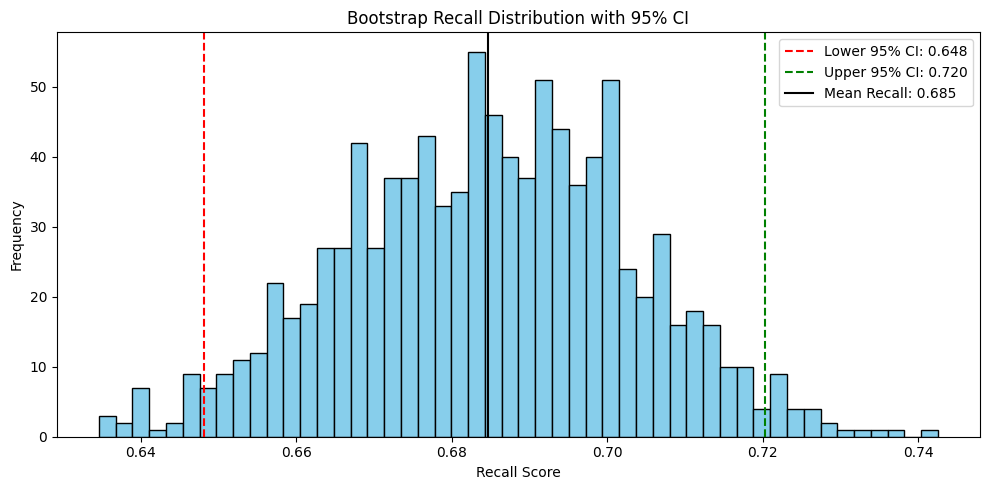

In [10]:
def bootstrap_ci_recall_distribution(y_true, y_pred_func, X, n_bootstraps=1000, alpha=0.95):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = recall_score(y_true.iloc[indices], y_pred_func(X.iloc[indices]))
        bootstrapped_scores.append(score)
    sorted_scores = np.sort(bootstrapped_scores)
    lower = np.percentile(sorted_scores, ((1-alpha)/2)*100)
    upper = np.percentile(sorted_scores, (alpha + (1-alpha)/2)*100)
    return bootstrapped_scores, lower, upper

# scores
recall_scores, lower_ci, upper_ci = bootstrap_ci_recall_distribution(
    y_test.reset_index(drop=True), 
    best_knn.predict, 
    X_test.reset_index(drop=True)
)

print(f"Recall 95% CI: ({lower_ci:.3f}, {upper_ci:.3f})")

# plot
plt.figure(figsize=(10, 5))
plt.hist(recall_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower_ci, color='red', linestyle='--', label=f"Lower 95% CI: {lower_ci:.3f}")
plt.axvline(upper_ci, color='green', linestyle='--', label=f"Upper 95% CI: {upper_ci:.3f}")
plt.axvline(np.mean(recall_scores), color='black', linestyle='-', label=f"Mean Recall: {np.mean(recall_scores):.3f}")
plt.title("Bootstrap Recall Distribution with 95% CI")
plt.xlabel("Recall Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Feature importance

             Feature  Base Importance  Best Importance
3              fever        -0.003146        -0.009934
4               area        -0.000993        -0.006291
9            gandaki         0.006623        -0.004967
11             koshi         0.004305        -0.002483
7   health insurance        -0.001490        -0.002318
2          diarrhoea         0.005464         0.002318
13           lumbini        -0.005960         0.009768
6   mother education        -0.005629         0.009768
14     sudurpashchim         0.009934         0.009934
5          child sex        -0.002483         0.010762
10           karnali         0.009603         0.021689
0          child age        -0.003974         0.025000
12           madhesh         0.025662         0.028974
8       wealth index         0.025497         0.029470
1       child weight         0.062252         0.112748


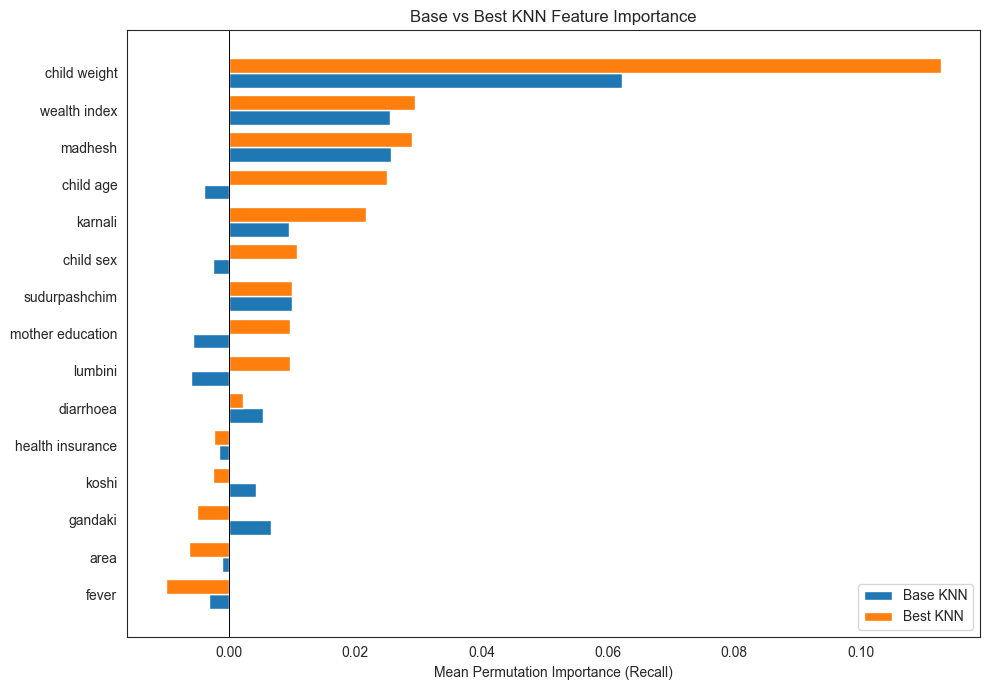

In [28]:
# Compute permutation importance for base_knn
base_result = permutation_importance(
    base_knn,
    X_test,
    y_test,
    scoring='recall',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Compute permutation importance for best_knn
best_result = permutation_importance(
    best_knn,
    X_test,
    y_test,
    scoring='recall',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create DataFrame with original (signed) values for both models
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Base Importance': base_result.importances_mean,
    'Best Importance': best_result.importances_mean
})

# Sort by best model’s importance (you could sort by base if you prefer)
importance_df = importance_df.sort_values(by='Best Importance')

print(importance_df)

# Plot both models' importances side by side
plt.figure(figsize=(10, 7))
bar_width = 0.4
features = importance_df['Feature']
y_pos = np.arange(len(features))

plt.barh(y_pos - bar_width/2, importance_df['Base Importance'], height=bar_width,  label='Base KNN')
plt.barh(y_pos + bar_width/2, importance_df['Best Importance'], height=bar_width,  label='Best KNN')

plt.yticks(y_pos, features)
plt.xlabel("Mean Permutation Importance (Recall)")
plt.title("Base vs Best KNN Feature Importance")
plt.axvline(x=0, color='black', linewidth=0.7)  # helps show negative/positive effects
plt.legend()
plt.tight_layout()
plt.show()


#### Alternative (Wilson method) for 95% CI 

In [13]:
# from statsmodels.stats.proportion import proportion_confint

# # Compute recall
# recall = recall_score(y_test, y_pred_tuned)

# # True positives and actual positives
# tp = sum((y_test == 1) & (y_pred_tuned == 1))
# total = sum(y_test == 1)

# # 95% CI using Wilson method
# lower, upper = proportion_confint(tp, total, alpha=0.05, method='wilson')
# print(f"Recall: {recall:.3f}, 95% CI: [{lower:.3f}, {upper:.3f}]")


### Average precision plot

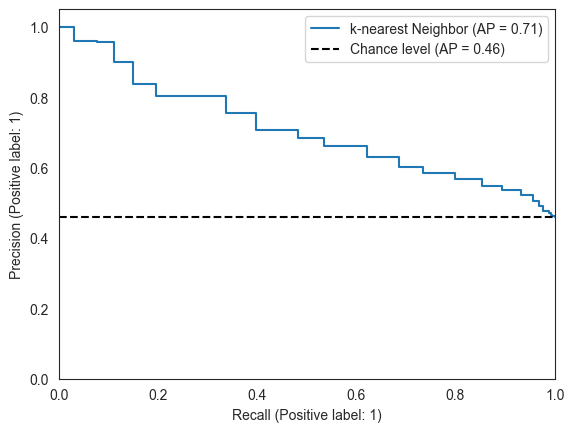

In [25]:
display = PrecisionRecallDisplay.from_estimator(
    best_knn,            # Trained model
    X_test,              # Test features
    y_test,              # True labels
    name="k-nearest Neighbor",          # Name for legend
    plot_chance_level=True  # Automatically plots chance-level baseline
)

# display.ax_.set_title("KNN Precision-Recall curve")
display.ax_.legend(loc='upper right')
display.ax_.set_xlim([0.0, 1.0])
display.ax_.set_ylim([0.0, 1.05])
plt.show()


## Additional

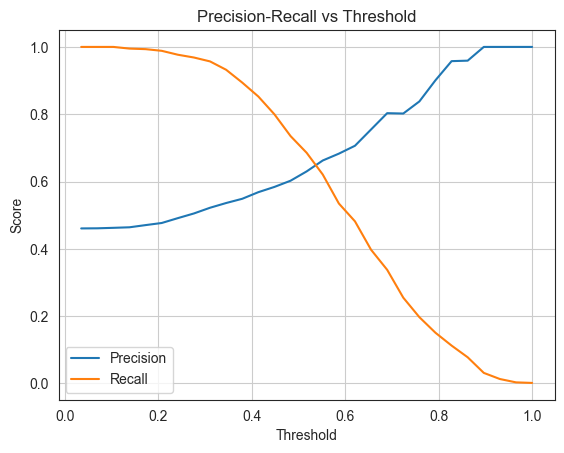

In [26]:
y_proba_tune = best_knn.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [27]:
# Apply custom threshold
y_proba_custom = (y_proba_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_proba_custom, digits = 3)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0      0.780     0.447     0.568       707
           1      0.568     0.853     0.682       604

    accuracy                          0.634      1311
   macro avg      0.674     0.650     0.625      1311
weighted avg      0.683     0.634     0.621      1311


